# Projects

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/git/https%3A%2F%2Fgitlab.in2p3.fr%2Fenergy4climate%2Fpublic%2Feducation%2Fmachine_learning_for_climate_and_energy/master?filepath=book%2Fnotebooks%2Fprojects.ipynb)

<div class="alert alert-block alert-warning">
    <b>Schedule</b>
    
- Ask your supervisors for the data if not already provided (it is not included in this repository).
- Quick presentation.
- Final project presentation.
    
</div>

<div class="alert alert-block alert-info">
    <b>One problematic, One dataset, One (or more) method(s)</b>
    
- Quality of the dataset is key.
- Results on a clean notebook.
- Explain which method(s) you used and why.
- If a method fails, explain why.

</div>

## Variable Renewable Energy (VRE) assessment and forecast

### Project objectives
<div class="alert alert-block alert-info">

- Assess the onshore wind or solar photovoltaic hourly production over in metropolitan France regions using climate data and capacity factor observations.
- Predict the VRE power ahead of time.
</div>

### Dataset

- Observed monthly VRE capacity factors averaged over metropolitan France regions from 2014 to 2021
- Climate variables of your choice from a global reanalysis with an hourly sampling from 2010 to 2019

### First steps

- Choose from solar or wind power
- Read about solar/wind production assessment and forecast
- Estimate the hourly solar/wind production

### Reading the data

<Axes: xlabel='time'>

<Figure size 640x480 with 0 Axes>

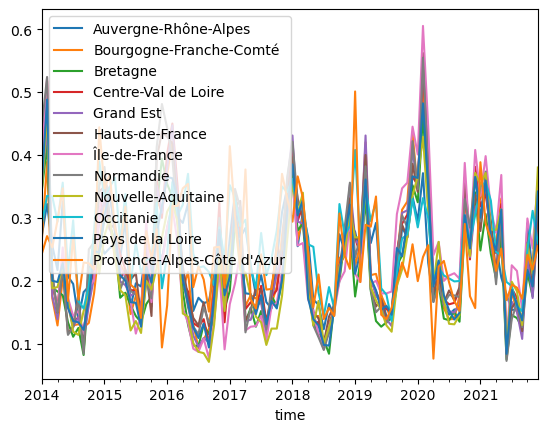

<Figure size 640x480 with 0 Axes>

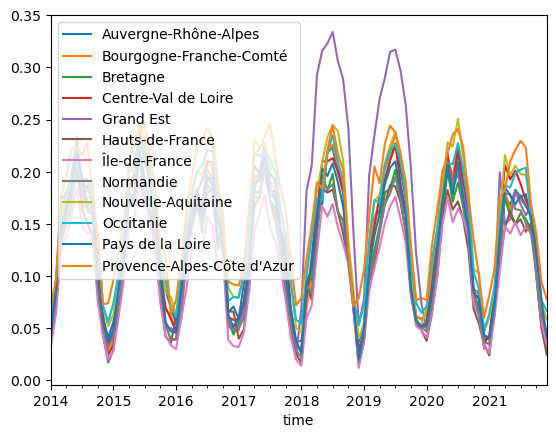

<Figure size 640x480 with 0 Axes>

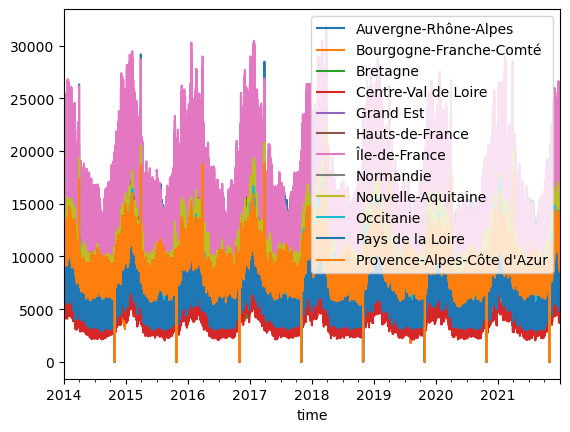

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

# Directories where you saved the data
data_dir_energy = Path('C:/Users/Bricout/Desktop/MEC - Machine learning/ml4climate/ml4climate/notebooks/projet/energy_france')
data_dir_climate = Path('C:/Users/Bricout/Desktop/MEC - Machine learning/ml4climate/ml4climate/notebooks/projet/climate_france')
                        
# Template filenames
filename_mask = 'mask_datagouv_french_regions_merra2_Nx_France.nc'
filename_climate = 'merra2_area_selection_output_{}_merra2_2010-2019.nc'
filename_energy = 'reseaux_energies_{}.csv'

"""
# Read and plot grid point-region mask
filepath_mask = Path(data_dir_climate, filename_mask)
ds_mask = xr.load_dataset(filepath_mask)
da_mask = ds_mask['mask']
plt.figure()
plt.scatter(da_mask['lon'], da_mask['lat'], c=da_mask, cmap='Set1')

# Compute regional mean of climate variable and plot time series
da_climate_reg = da_climate.groupby(da_mask).mean().rename(mask='region')
da_climate_reg['region'] = ds_mask['region'].values
plt.figure()
da_climate_reg.plot.line(x='time')
"""

# Read energy variable and plot time series
variable_name = 'capacityfactor_wind-onshore'
filename = filename_energy.format(variable_name)
filepath = Path(data_dir_energy, filename)
df_energy_wind = pd.read_csv(filepath, index_col=0, header=0, parse_dates=True)
plt.figure()
df_energy_wind.plot()


variable_name = 'capacityfactor_pv'
filename = filename_energy.format(variable_name)
filepath = Path(data_dir_energy, filename)
df_energy_pv = pd.read_csv(filepath, index_col=0, header=0, parse_dates=True)
plt.figure()
df_energy_pv.plot()

variable_name = 'demand_demand'
filename = filename_energy.format(variable_name)
filepath = Path(data_dir_energy, filename)
df_energy_demand = pd.read_csv(filepath, index_col=0, header=0, parse_dates=True)
plt.figure()
df_energy_demand.plot()



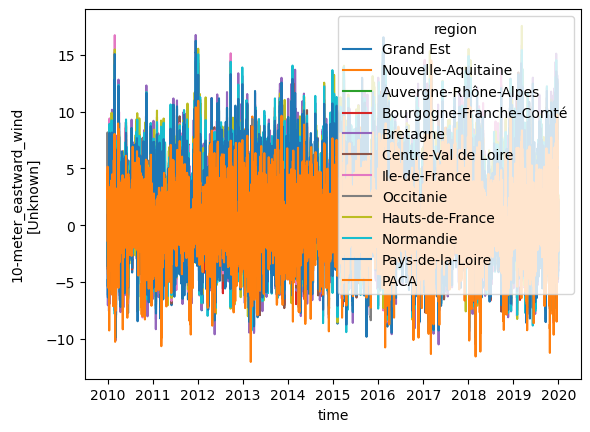

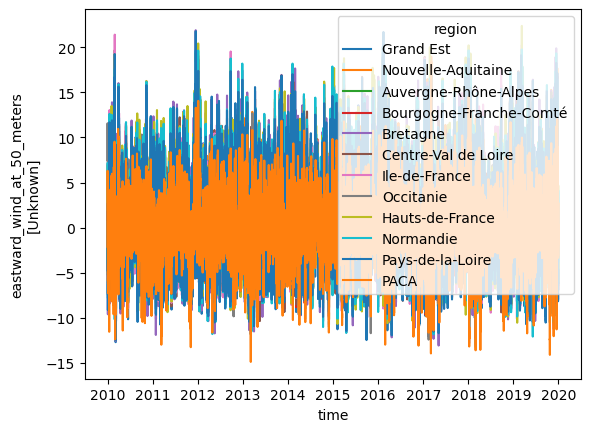

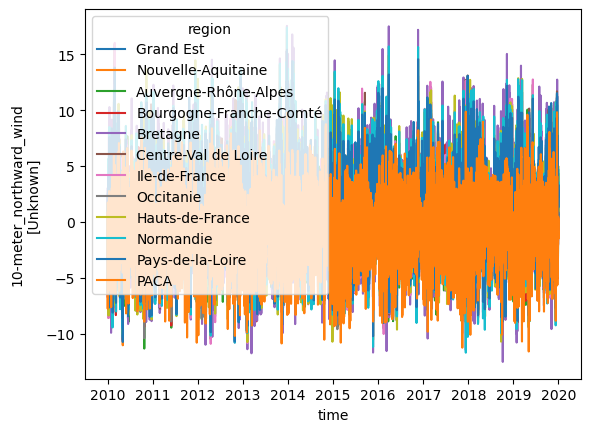

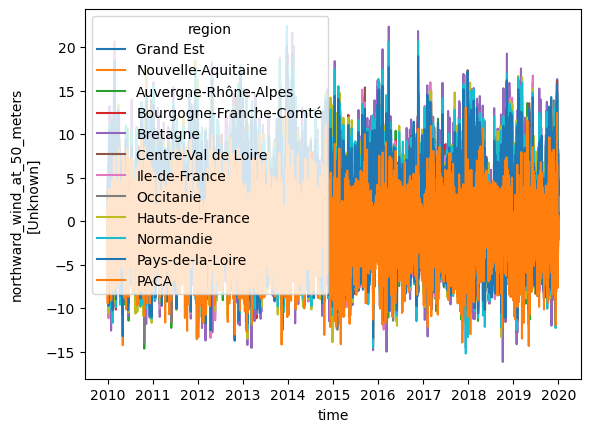

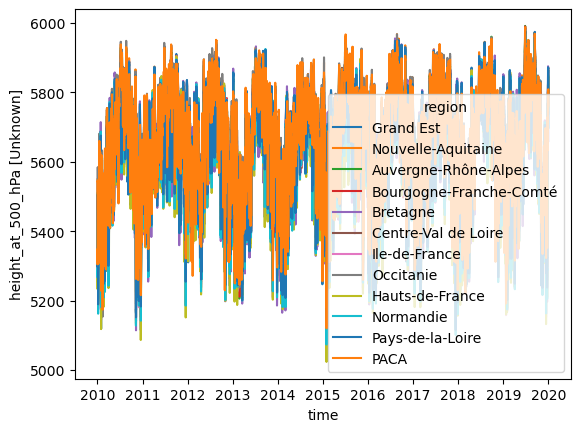

In [9]:
# Read a climate variable and plot its mean over time
filepath_mask = Path(data_dir_climate, filename_mask)
ds_mask = xr.load_dataset(filepath_mask)
da_mask = ds_mask['mask']

variable_name = 'zonal_wind'
filename = filename_climate.format(variable_name)
filepath = Path(data_dir_climate, filename)
da_climate_zonal_wind = xr.load_dataset(filepath)[variable_name]
da_climate_reg_zonal_wind = da_climate_zonal_wind.groupby(da_mask).mean().rename(mask='region')
da_climate_reg_zonal_wind['region'] = ds_mask['region'].values
plt.figure()
da_climate_reg_zonal_wind.plot.line(x='time')

variable_name = 'upper_zonal_wind'
filename = filename_climate.format(variable_name)
filepath = Path(data_dir_climate, filename)
da_climate_upper_zonal_wind = xr.load_dataset(filepath)[variable_name]
da_climate_reg_upper_zonal_wind = da_climate_upper_zonal_wind.groupby(da_mask).mean().rename(mask='region')
da_climate_reg_upper_zonal_wind['region'] = ds_mask['region'].values
plt.figure()
da_climate_reg_upper_zonal_wind.plot.line(x='time')

variable_name = 'meridional_wind'
filename = filename_climate.format(variable_name)
filepath = Path(data_dir_climate, filename)
da_climate_meridional_wind = xr.load_dataset(filepath)[variable_name]
da_climate_reg_meridional_wind = da_climate_meridional_wind.groupby(da_mask).mean().rename(mask='region')
da_climate_reg_meridional_wind['region'] = ds_mask['region'].values
plt.figure()
da_climate_reg_meridional_wind.plot.line(x='time')

variable_name = 'upper_meridional_wind'
filename = filename_climate.format(variable_name)
filepath = Path(data_dir_climate, filename)
da_climate_upper_meridional_wind = xr.load_dataset(filepath)[variable_name]
da_climate_reg_upper_meridional_wind = da_climate_upper_meridional_wind.groupby(da_mask).mean().rename(mask='region')
da_climate_reg_upper_meridional_wind['region'] = ds_mask['region'].values
plt.figure()
da_climate_reg_upper_meridional_wind.plot.line(x='time')


variable_name = 'height_500'
filename = filename_climate.format(variable_name)
filepath = Path(data_dir_climate, filename)
da_climate_height_500 = xr.load_dataset(filepath)[variable_name]
da_climate_height_500 = da_climate_height_500.groupby(da_mask).mean().rename(mask='region')
da_climate_height_500['region'] = ds_mask['region'].values
plt.figure()
da_climate_height_500.plot.line(x='time')


In [11]:
print(da_climate_reg_zonal_wind)
print(da_climate_reg_zonal_wind['region'])
print(da_climate_reg_zonal_wind.region.values)


<xarray.DataArray 'zonal_wind' (time: 87648, region: 12)> Size: 4MB
array([[ 0.22277811,  3.5737722 , -0.9044757 , ..., -2.780189  ,
        -3.6027389 , -1.3628596 ],
       [ 0.00771113,  3.6454117 , -0.54947543, ..., -2.5554788 ,
        -2.9629717 , -1.1930856 ],
       [-0.2037364 ,  3.5405803 , -0.00481807, ..., -2.3765986 ,
        -2.282671  , -0.7620747 ],
       ...,
       [-3.0207803 ,  0.89953196,  0.03351669, ..., -0.8011123 ,
        -0.4198756 ,  0.020197  ],
       [-2.681016  ,  0.8455611 ,  0.3114346 , ..., -1.0764267 ,
        -0.5061009 , -0.18392676],
       [-2.2938192 ,  0.8317019 ,  0.48794514, ..., -1.2849905 ,
        -0.4189906 , -0.39078128]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 701kB 2010-01-01 ... 2019-12-31T23:00:00
  * region   (region) <U23 1kB 'Grand Est' 'Nouvelle-Aquitaine' ... 'PACA'
Attributes:
    long_name:       10-meter_eastward_wind
    units:           Unknown
    fmissing_value:  1000000000000000.0
    standard_na

In [25]:
region_names = ds_mask['region'].values
idx_grand_est = np.where(region_names == 'Grand Est')[0][0]

variables = {
    'zonal_wind': da_climate_reg_zonal_wind,
    'upper_zonal_wind': da_climate_reg_upper_zonal_wind,
    'meridional_wind': da_climate_reg_meridional_wind,
    'upper_meridional_wind': da_climate_reg_upper_meridional_wind,
    'height_500': da_climate_height_500,  # Corriger si mauvaise variable !
}


region_names = ds_mask['region'].values

# récupération de l'indice de la région Grand Est
idx_grand_est = np.where(region_names == 'Grand Est')[0][0]

df_grand_est = pd.DataFrame()

for var_name, da in variables.items():

    # on vérifie le nom de la dimension région
    region_dim = 'region' if 'region' in da.coords else 'mask'

    # extraction
    df_grand_est[var_name] = da.isel({region_dim: idx_grand_est}).to_pandas()

df_grand_est = df_grand_est.resample('MS').mean().loc['2014-01-01':'2019-12-31']

df_grand_est["capacityfactor_wind_onshore"] = df_energy_wind["Grand Est"].loc['2014-01-01':'2019-12-31']

display(df_grand_est)



,zonal_wind,upper_zonal_wind,meridional_wind,upper_meridional_wind,height_500,capacityfactor_wind_onshore
time,,,,,,
2014-01-01,0.929677,1.445020,3.072169,4.464924,5457.524902,0.354
2014-02-01,1.694000,2.582272,4.090259,5.911065,5433.682129,0.445
2014-03-01,0.098000,-0.066601,0.424784,0.586957,5576.511230,0.176
2014-04-01,0.388645,0.504478,-0.087575,-0.155022,5592.030762,0.139
2014-05-01,0.971246,1.352343,0.441678,0.602557,5617.010254,0.231
...,...,...,...,...,...,...
2019-08-01,1.032243,1.456975,0.547246,0.771876,5776.730469,0.128
2019-09-01,0.845473,1.133797,0.049685,0.019742,5748.557129,0.229
2019-10-01,1.147394,1.790839,2.066456,3.204923,5669.223633,0.308


R2 : 0.7887072742725008
Intercept : 0.22593056
Coefficients : [ 0.14425653 -0.14095896  0.36870104 -0.32072586 -0.04800731]


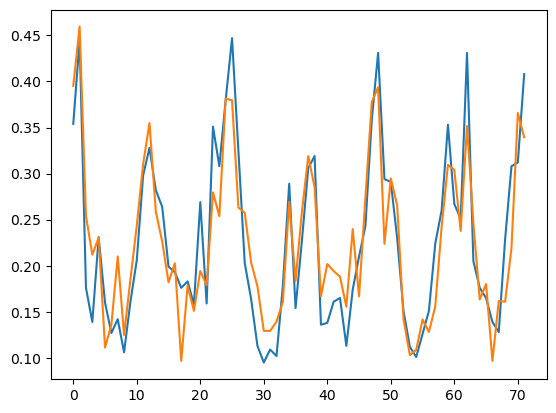

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


X_train = df_grand_est[['zonal_wind','upper_zonal_wind','meridional_wind','upper_meridional_wind','height_500']].values
y_train = df_grand_est['capacityfactor_wind_onshore'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Régression
reg = LinearRegression()
reg.fit(X_scaled, y_train)

print("R2 :", reg.score(X_scaled, y_train))
print("Intercept :", reg.intercept_)
print("Coefficients :", reg.coef_)

y_pred = reg.predict(X_scaled)

plt.plot(y_train)
plt.plot(y_pred)

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


X_train = df_grand_est['height_500'].values[:,None]
y_train = df_grand_est['capacityfactor_wind_onshore'].values

reg = linear_model.LinearRegression(fit_intercept=True)

reg.fit(X_train, y_train)

print("R2 :", reg.score(X_train, y_train))
print("Intercept :", reg.intercept_)
print("Coefficients :", reg.coef_)

R2 : 0.5473632977912206
Intercept : 3.7645106
Coefficients : [-0.00062809]


***
## Credit

[//]: # "This notebook is part of [E4C Interdisciplinary Center - Education](https://gitlab.in2p3.fr/energy4climate/public/education)."
Contributors include Bruno Deremble and Alexis Tantet.
Several slides and images are taken from the very good [Scikit-learn course](https://inria.github.io/scikit-learn-mooc/).

<br>

<div style="display: flex; height: 70px">
    
<img alt="Logo LMD" src="images/logos/logo_lmd.jpg" style="display: inline-block"/>

<img alt="Logo IPSL" src="images/logos/logo_ipsl.png" style="display: inline-block"/>

<img alt="Logo E4C" src="images/logos/logo_e4c_final.png" style="display: inline-block"/>

<img alt="Logo EP" src="images/logos/logo_ep.png" style="display: inline-block"/>

<img alt="Logo SU" src="images/logos/logo_su.png" style="display: inline-block"/>

<img alt="Logo ENS" src="images/logos/logo_ens.jpg" style="display: inline-block"/>

<img alt="Logo CNRS" src="images/logos/logo_cnrs.png" style="display: inline-block"/>
    
</div>

<hr>

<div style="display: flex">
    <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0; margin-right: 10px" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a>
    <br>This work is licensed under a &nbsp; <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/">Creative Commons Attribution-ShareAlike 4.0 International License</a>.
</div>